<a href="https://colab.research.google.com/github/victorcetre/03MIAR-Algoritmos-de-Optimizacion/blob/main/Algoritmos_Victor_Andres_Cetre_Rodriguez_AG2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos - Victor Andres Cetre Rodriguez - AG2

Estudiante: Victor Andres Cetre Rodriguez

URL: https://colab.research.google.com/drive/1PEhC_vcjZZ4TyIoaia8NZdwpeRP-igUR?usp=sharing

Github: https://github.com/victorcetre/03MIAR-Algoritmos-de-Optimizacion


##Programación Dinámica. Viaje por el rio (repaso)

In [ ]:
TARIFAS = [
[0,   5,   4,   3,   999, 999, 999],
[999, 0,   999, 2,   3,   999, 11],
[999, 999, 0,   1,   999, 4,   10],
[999, 999, 999, 0,   5,   6,   9],
[999, 999, 999, 999, 0,   999, 4],
[999, 999, 999, 999, 999, 0,   3],
[999, 999, 999, 999, 999, 999, 0]
]


def Precios(TARIFAS):
  N = len(TARIFAS[0])
  PRECIOS = [[9999]*N for _ in range(N)]
  RUTA = [[""]*N for _ in range(N)]

  for i in range(0, N-1):
    RUTA[i][i] = i
    PRECIOS[i][i] = 0
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i
      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
          MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j])
          RUTA[i][j] = k
        PRECIOS[i][j] = MIN

  return PRECIOS, RUTA


def calcular_ruta(RUTA, desde, hasta):
  if desde == hasta:
    return [desde]
  return calcular_ruta(RUTA, desde, RUTA[desde][hasta]) + [hasta]


PRECIOS, RUTA = Precios(TARIFAS)
print("Ruta de 0 a 6:", calcular_ruta(RUTA, 0, 6), " coste:", PRECIOS[0][6])


Ruta de 0 a 6: [0, 2, 5, 6]  coste: 11


##Asignación de tareas por Ramificación y Poda

In [ ]:
#BENEFICIOS[tarea][agente] -> beneficio de asignar esa tarea a ese agente
BENEFICIOS = [
    [9, 2, 7, 8],
    [6, 4, 3, 7],
    [5, 8, 1, 8],
    [7, 6, 9, 4],
]


#S es una solucion parcial (a0,a1,...) -> a la tarea i se le asigna el agente ai
def valor(S, BENEFICIOS):
  return sum(BENEFICIOS[i][S[i]] for i in range(len(S)))


def crear_hijos(S, N):
  usados = set(S)
  return [S + (a,) for a in range(N) if a not in usados]


#Fuerza bruta: prueba todas las permutaciones
import itertools


def fuerza_bruta(N, BENEFICIOS):
  mejor_valor = -1
  mejor_sol = None
  for perm in itertools.permutations(range(N)):
    v = valor(perm, BENEFICIOS)
    if v > mejor_valor:
      mejor_valor = v
      mejor_sol = perm
  return mejor_sol, mejor_valor


N = len(BENEFICIOS)
print(fuerza_bruta(N, BENEFICIOS))


((0, 3, 1, 2), 33)


In [ ]:
#Cota superior de una solucion parcial: lo ya conseguido + lo mejor posible en cada tarea
#restante con cualquier agente aun libre (sobreestima, nunca poda una rama buena)
def cota_superior(S, BENEFICIOS, N):
  usados = set(S)
  total = valor(S, BENEFICIOS)
  for i in range(len(S), N):
    disponibles = [BENEFICIOS[i][a] for a in range(N) if a not in usados]
    total += max(disponibles) if disponibles else 0
  return total


#Solucion voraz completa: nos da una cota inferior valida desde la que empezar a podar
def solucion_voraz(N, BENEFICIOS):
  usados = set()
  sol = []
  for i in range(N):
    disponibles = [a for a in range(N) if a not in usados]
    mejor_a = max(disponibles, key=lambda a: BENEFICIOS[i][a])
    sol.append(mejor_a)
    usados.add(mejor_a)
  return tuple(sol)


def ramificacion_y_poda(N, BENEFICIOS):
  mejor_sol = solucion_voraz(N, BENEFICIOS)
  mejor_valor = valor(mejor_sol, BENEFICIOS)

  NODOS = [()]
  while NODOS:
    #Exploramos primero el nodo mas prometedor (mayor cota superior)
    NODOS.sort(key=lambda s: cota_superior(s, BENEFICIOS, N), reverse=True)
    nodo = NODOS.pop(0)

    if len(nodo) > 0 and cota_superior(nodo, BENEFICIOS, N) <= mejor_valor:
      continue  #Poda: esta rama no puede mejorar la mejor solucion conocida

    for hijo in crear_hijos(nodo, N):
      if cota_superior(hijo, BENEFICIOS, N) <= mejor_valor:
        continue
      if len(hijo) == N:
        v = valor(hijo, BENEFICIOS)
        if v > mejor_valor:
          mejor_valor = v
          mejor_sol = hijo
      else:
        NODOS.append(hijo)

  return mejor_sol, mejor_valor


print(ramificacion_y_poda(N, BENEFICIOS))


((0, 3, 1, 2), 33)


###Mejora de nota: comparar tiempos con matrices aleatorias mas grandes

In [ ]:
import random
import time


def generar_matriz(n, seed=0):
  random.seed(seed)
  return [[random.randint(1, 50) for _ in range(n)] for _ in range(n)]


for n in [4, 6, 8, 9, 10]:
  M = generar_matriz(n, seed=42)

  t0 = time.perf_counter()
  _, v_fb = fuerza_bruta(n, M)
  t1 = time.perf_counter()

  _, v_ryp = ramificacion_y_poda(n, M)
  t2 = time.perf_counter()

  print("n=", n, " fuerza_bruta=", round(t1-t0, 4), "s  ramificacion_poda=", round(t2-t1, 4), "s  coinciden=", v_fb == v_ryp)

#A partir de n~10 la fuerza bruta (N! permutaciones) empieza a ser inviable.
#Ramificacion y poda aguanta mucho mas porque la cota superior descarta ramas enteras,
#pero para matrices aleatorias sin estructura tambien acaba degenerando a un
#comportamiento exponencial cuando faltan pocas podas efectivas.


n= 4  fuerza_bruta= 0.0001 s  ramificacion_poda= 0.0003 s  coinciden= True
n= 6  fuerza_bruta= 0.0012 s  ramificacion_poda= 0.0014 s  coinciden= True
n= 8  fuerza_bruta= 0.0563 s  ramificacion_poda= 0.0045 s  coinciden= True
n= 9  fuerza_bruta= 0.5285 s  ramificacion_poda= 0.3281 s  coinciden= True
n= 10  fuerza_bruta= 6.7257 s  ramificacion_poda= 0.1476 s  coinciden= True


##Descenso del Gradiente

In [ ]:
import math


#Paraboloide f(x,y) = x^2 + y^2, minimo conocido en (0,0)
f = lambda X: X[0]**2 + X[1]**2
df = lambda X: [2*X[0], 2*X[1]]


def descenso_gradiente(f, df, p0, alpha=0.1, iteraciones=1000, tol=1e-8):
  p = list(p0)
  historia = [p[:]]
  for _ in range(iteraciones):
    grad = df(p)
    p = [p[i] - alpha*grad[i] for i in range(len(p))]
    historia.append(p[:])
    if math.sqrt(sum(g**2 for g in grad)) < tol:
      break
  return p, f(p), historia


import random
random.seed(0)
p0 = [random.uniform(-5, 5), random.uniform(-5, 5)]
p_final, f_final, historia = descenso_gradiente(f, df, p0, alpha=0.1, iteraciones=500)
print("punto inicial:", p0)
print("punto final:", p_final, " f:", f_final, " iteraciones:", len(historia))


punto inicial: [3.4442185152504816, 2.5795440294030243]
punto final: [2.6763904670419975e-09, 2.004479976819146e-09]  f: 1.1181005909542165e-17  iteraciones: 95


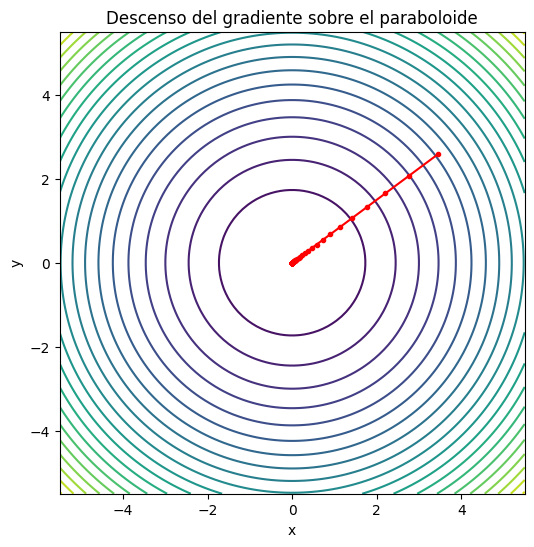

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

resolucion = 100
rango = 5.5
X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
XX, YY = np.meshgrid(X, Y)
ZZ = XX**2 + YY**2

plt.figure(figsize=(6, 6))
plt.contour(XX, YY, ZZ, levels=20)
hx = [p[0] for p in historia]
hy = [p[1] for p in historia]
plt.plot(hx, hy, "r.-")
plt.title("Descenso del gradiente sobre el paraboloide")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


###Mejora de nota: minimizar una función no convexa

In [ ]:
#f(x,y) = sin(0.5x^2 - 0.25y^2 + 3) * cos(2x + 1 - e^y)
def f2(X):
  x, y = X
  return math.sin(0.5*x**2 - 0.25*y**2 + 3) * math.cos(2*x + 1 - math.exp(y))


def df2(X):
  x, y = X
  s = math.sin(0.5*x**2 - 0.25*y**2 + 3)
  c = math.cos(0.5*x**2 - 0.25*y**2 + 3)
  cs = math.cos(2*x + 1 - math.exp(y))
  sn = math.sin(2*x + 1 - math.exp(y))

  dfx = c*x*cs - 2*s*sn
  dfy = -0.5*c*y*cs + s*sn*math.exp(y)
  return [dfx, dfy]


#Al no ser convexa, el descenso puede quedarse en un minimo local segun el punto
#de partida. Hacemos varios arranques aleatorios y nos quedamos con el mejor.
mejor_p = None
mejor_f = float("inf")
for _ in range(30):
  p0 = [random.uniform(-3, 3), random.uniform(-3, 3)]
  p_final, f_final, _ = descenso_gradiente(f2, df2, p0, alpha=0.05, iteraciones=300)
  if f_final < mejor_f:
    mejor_f = f_final
    mejor_p = p_final

print("mejor minimo encontrado (multiarranque):", mejor_p, mejor_f)


mejor minimo encontrado (multiarranque): [-2.027650616554455, 1.171826837348781] -1.0
